In [13]:
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [20]:
import pywt, math
from dst.filters import get_filters
from scripts.test_signal_gen import x, y
import matplotlib.pyplot as plt
import numpy as np

pattern = [(0, 0.20), (1, 0.50), (2, 0.45), ( 3, 0.85), (4, 0.80), (5, -0.75), (6, 0.25), (7, 0.20), (8, 0.55)]

dec_lo, dec_hi, rec_lo, rec_hi = get_filters(pattern)
filter_bank = [[i for i in dec_lo.values()], [i for i in dec_hi.values()], [i for i in rec_lo.values()], [i for i in rec_hi.values()]]
myWavelet = pywt.Wavelet(name="myWavelet", filter_bank=filter_bank)

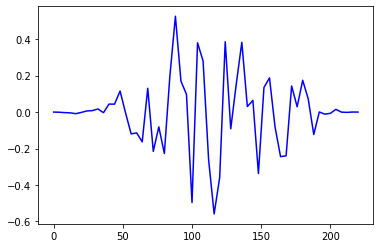

In [22]:
phi_d, psi_d, phi_r, psi_r, x = myWavelet.wavefun(5)
phi_x = [i for i in range(0, len(phi_d), 8)]
phi_d_ = [phi_d[i] for i in range(0, len(phi_d), 8)]
# plt.plot(phi_x, phi_d_, 'r-')
psi_x = [i for i in range(0, len(psi_d), 4)]
psi_d_ = [psi_d[i] for i in range(0, len(psi_d), 4)]
plt.plot(psi_x, psi_d_, 'b-')
plt.show()

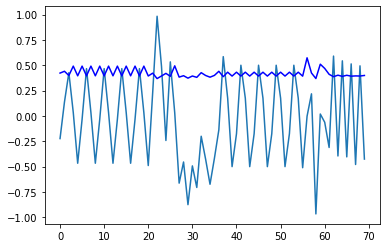

In [23]:
# y = [1,2,3,4,5,6]
# db1 = pywt.Wavelet(name = 'db1')
# (cA, cD) = pywt.dwt(y, 'db1')
# (cA1, cD1) = pywt.dwt(y, myWavelet)
(cA, cD) = pywt.dwt(y, myWavelet)
# cA = pywt.downcoef('a', y, myWavelet)

y_ = [i for i in cD]
y_ += [i for i in cA]
alpha = 0.1
y_1 = [math.exp(-(np.abs(y_[i])**alpha)) for i in range(len(y_))]
x_ = [i for i in range(70)]
plt.plot(x_, y_)
plt.plot(x_, y_1, 'b-')
plt.show()